## Figures 4B-D

In [53]:
from tkinter.filedialog import askdirectory
from tkinter import Tk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import pickle
import os
os.environ["OUTDATED_IGNORE"] = "1"
from pathlib import Path
from itertools import compress
import datetime
import seaborn as sns
import pingouin as pg
from statsmodels.stats.multitest import multipletests
cur_dir = Path(os.getcwd())
src_dir = cur_dir.parent.parent
os.chdir(src_dir)
from functions.scale_bars import add_scalebar
from functions.date_range import date_range
from functions.photom_plots import make_hboxplot, plot_mean_sem, plot_sem_ax
os.chdir(cur_dir)

#######################################
# Set these variables
ConditionsToPlot = ['fed','6pm-8am fast']
colors = ['purple','green']
MovingMeanVals = [30] # values over which to take moving mean for plots, in mins

# Select only trials beginning at a particular time
# Enter 'All' to include all trials, or number for trials starting at specific hour (in Zeitgeber time - lights on = 0)
TrialsBeginning = 'All'

# Set period to use as F0, for each condition
f0_period = {
              'fed': date_range(datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,1,9,0), 1, 'seconds'),
             '6pm-8am fast': date_range(datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,1,9,0), 1, 'seconds')
             }

start_time = 6
end_date = 2
end_time = 5
#######################################

ColorsToUse = colors[0:len(colors)]
plt.rcParams['figure.figsize'] = [9,10.5] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams.update({'font.size': 16})

In [54]:
# Open a dialog box to select the directory to be analyzed
# (so that this code block can be run independently of the merging block above)
window = Tk()
window.wm_attributes('-topmost', 1)
window.withdraw()
Dir2 = askdirectory(parent = window)
os.chdir(Dir2 + '/')

# Load data
with open('AllTrialsData.pkl', 'rb') as f:
    AllTrials = pickle.load(f)

# Select trials with correct start time
if TrialsBeginning == 'All':
    UseTheseTrials = AllTrials['MouseTrialID']
else:
    # Select MouseTrialIDs that have a sample at this start time
    UseTheseTrials = list(compress(AllTrials['MouseTrialID'],AllTrials['dFF0'].loc[datetime.datetime(1,1,1,TrialsBeginning,0)].notnull()))
    # Now discard MouseTrialIDs that start before this time..
    if AllTrials['dFF0'].index[0] < datetime.datetime(1,1,1,TrialsBeginning,0):
        # Make a list of all the trials that have a time point 1h before desired start time
        NotTheseTrials = list(compress(AllTrials['MouseTrialID'],AllTrials['dFF0'].loc[datetime.datetime(1,1,1,TrialsBeginning-1,0)].notnull()))
        # Remove these trials
        UseTheseTrials = list(set(UseTheseTrials)-set(NotTheseTrials))
        del(NotTheseTrials)

In [55]:
# Recalculate dF/F0 and z-score

my_cols = pd.MultiIndex(levels = [[],[],[]], codes = [[],[],[]],
                            names = ['MouseID', 'MouseTrialID', 'Stim'])

AllTrials['dFF0'] = pd.DataFrame(columns=my_cols)
AllTrials['z-score'] = pd.DataFrame(columns=my_cols)

for cond in ConditionsToPlot:
    this_cond_trials = AllTrials['Raw_DS'].xs(cond, level=2, axis=1)
    f0 = this_cond_trials.loc[f0_period[cond]].mean()
    dff0 = (this_cond_trials - f0) / f0
    mn = dff0.loc[f0_period[cond]].mean()
    std = dff0.loc[f0_period[cond]].std()
    zs = (this_cond_trials - f0) / std

    dff0 = pd.concat([dff0], keys=[cond], names=['Stim'], axis=1)
    dff0 = dff0.reorder_levels(['MouseID', 'MouseTrialID', 'Stim'], axis=1)
    AllTrials['dFF0'] = pd.concat([AllTrials['dFF0'], dff0], axis=1)
    zs = pd.concat([zs], keys=[cond], names=['Stim'], axis=1)
    zs = zs.reorder_levels(['MouseID', 'MouseTrialID', 'Stim'], axis=1)
    AllTrials['z-score'] = pd.concat([AllTrials['z-score'], dff0], axis=1)

In [56]:
# Take moving means

Moving_Means = {}
# Loop through window sizes
for MM in MovingMeanVals:
    Moving_Means[MM] = {}
    # take moving mean with the given window size (assumes downsampling rate is the same for all trials)
    Moving_Means[MM]['dFF0'] = AllTrials['dFF0'].rolling(window = MM*60*AllTrials['DownSamplingRate'][0], center = False).mean()
    Moving_Means[MM]['z-score'] = pd.DataFrame(columns=my_cols)
    # then take z-score
    for cond in ConditionsToPlot:
        this_cond_trials = Moving_Means[MM]['dFF0'].xs(cond, level=2, axis=1)
        mn = this_cond_trials.loc[f0_period[cond]].mean()
        std = this_cond_trials.loc[f0_period[cond]].std()
        zs = (this_cond_trials - mn) / std
        zs = pd.concat([zs], keys=[cond], names=['Stim'], axis=1)
        zs = zs.reorder_levels(['MouseID', 'MouseTrialID', 'Stim'], axis=1)
        Moving_Means[MM]['z-score'] = pd.concat([Moving_Means[MM]['z-score'], zs], axis=1)

# Downstream analysis will be done on both moving mean and raw signals - therefore, also add raw data to this dataframe
Moving_Means['Raw'] = {}
Moving_Means['Raw']['dFF0'] = AllTrials['dFF0']
Moving_Means['Raw']['z-score'] = AllTrials['z-score']

In [57]:
# For each condition, calculate mean over trials for each mouse, then take grand mean over mice

# Initialize dicts. First level key = moving mean window size; second level key = signal (dFF0 or z-score).
Mouse_Means = {}
Mean_Over_Mice = {}
SEM_Over_Mice = {}

# Loop through moving mean values
my_cols = pd.MultiIndex(levels = [[],[]], codes = [[],[]],
                            names = [u'MouseID',u'Stim'])
for MM in Moving_Means.keys():
    Mouse_Means[MM] = {'dFF0':pd.DataFrame(index = Moving_Means[MM]['dFF0'].index, columns = my_cols), 
                'z-score':pd.DataFrame(index = Moving_Means[MM]['z-score'].index, columns = my_cols)}
    Mean_Over_Mice[MM] = {'dFF0':pd.DataFrame(index = AllTrials['dFF0'].index),
                'z-score':pd.DataFrame(index = AllTrials['z-score'].index)}
    SEM_Over_Mice[MM] = {'dFF0':pd.DataFrame(index = AllTrials['dFF0'].index),
                'z-score':pd.DataFrame(index = AllTrials['z-score'].index)}
    # Loop through conditions
    for Stim in ConditionsToPlot:
        # Get trials for this condition
        ThisStimTrials_dFF0 = Moving_Means[MM]['dFF0'].xs(Stim, level=2, axis=1)
        ThisStimTrials_ZS = Moving_Means[MM]['z-score'].xs(Stim, level=2, axis=1)
        # Loop through mice for this condition
        for Mouse in list(set(ThisStimTrials_dFF0.columns.get_level_values('MouseID'))):
            # Take mean over trials for this mouse
            Mouse_Means[MM]['dFF0'] = pd.concat([Mouse_Means[MM]['dFF0'],
                                            pd.DataFrame(ThisStimTrials_dFF0.xs(Mouse, level=0, axis=1).mean(axis=1),
                                                        columns = pd.MultiIndex.from_arrays([[Mouse],[Stim]], names = ['MouseID', 'Stim']))
                                            ], axis=1)
            Mouse_Means[MM]['z-score'] = pd.concat([Mouse_Means[MM]['z-score'],
                                            pd.DataFrame(ThisStimTrials_ZS.xs(Mouse, level=0, axis=1).mean(axis=1),
                                                        columns = pd.MultiIndex.from_arrays([[Mouse],[Stim]], names = ['MouseID', 'Stim']))
                                            ], axis=1)
        # Take mean and SEM over mice for this condition
        Mean_Over_Mice[MM]['dFF0'][Stim] = Mouse_Means[MM]['dFF0'].xs(Stim, level=1, axis=1).mean(axis=1)
        SEM_Over_Mice[MM]['dFF0'][Stim] = Mouse_Means[MM]['dFF0'].xs(Stim, level=1, axis=1).sem(axis=1)
        Mean_Over_Mice[MM]['z-score'][Stim] = Mouse_Means[MM]['z-score'].xs(Stim, level=1, axis=1).mean(axis=1)
        SEM_Over_Mice[MM]['z-score'][Stim] = Mouse_Means[MM]['z-score'].xs(Stim, level=1, axis=1).sem(axis=1)

In [58]:
# Get event labels for each condition
EventLabels = pd.DataFrame()
for Stim in ConditionsToPlot:
    EventLabels[Stim] = AllTrials['Events'][[AllTrials['MouseTrialID'][i] for i in range(len(AllTrials['Condition'])) if AllTrials['Condition'][i] == Stim][0]]
# Remove labels at the time of lights-on and off - we don't need to add these to the plot
EventLabels = EventLabels.loc[[i.time() != datetime.time(12,0) for i in EventLabels.index]]
EventLabels = EventLabels.loc[[i.time() != datetime.time(0,0) for i in EventLabels.index]]

In [59]:
# Cut data
start_time = datetime.datetime(1,1,1,start_time,0,0)
end_time = datetime.datetime(1,1,end_date,end_time,0,0)
start_to_end = date_range(start_time, end_time, 1, 'seconds')

for MM in MovingMeanVals:
    for k in Mean_Over_Mice[MM].keys():
        Mean_Over_Mice[MM][k] = Mean_Over_Mice[MM][k].loc[start_to_end]
        SEM_Over_Mice[MM][k] = SEM_Over_Mice[MM][k].loc[start_to_end]

C:\Users\sjwal\AppData\Local\Temp\ipykernel_27404\2413615.py:22: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot([j,j],ylim)


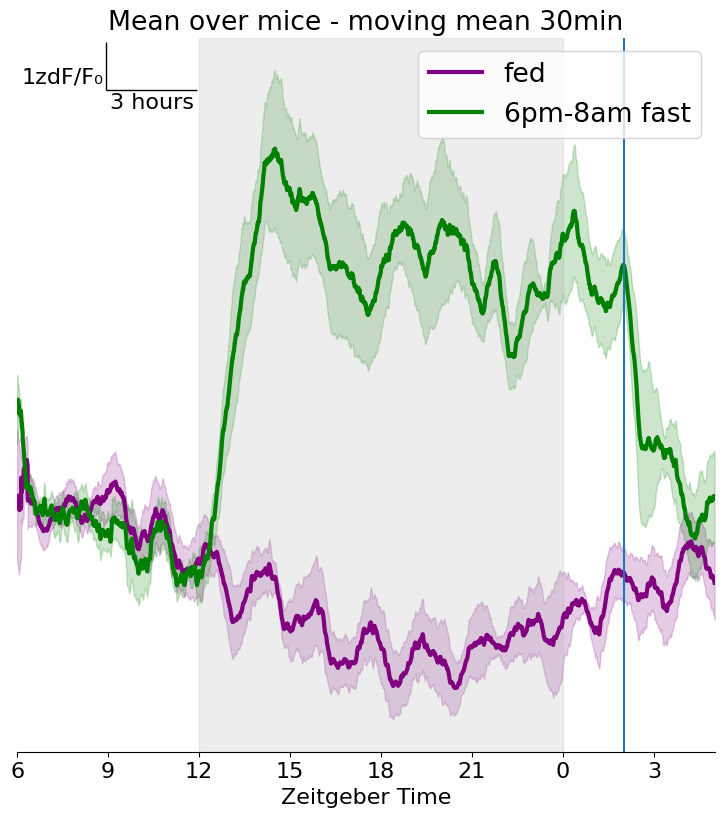

In [60]:
# Now plot different moving mean window values, dF/F0 and z-score in separate figures
for mm in MovingMeanVals:
    # Loop through dFF0/z-score
    signal = "z-score"
    fig, ax = plot_mean_sem(Mean_Over_Mice[mm][signal],
                            SEM_Over_Mice[mm][signal],
                            ConditionsToPlot,
                            ColorsToUse)
    ax.set(ylabel = signal, xlabel = 'Zeitgeber Time', title = 'Mean over mice - moving mean '+str(mm)+'min')
    if signal == 'dFF0':
            sizey = 0.01
            labely = u'1% dF/F\u2080'
    elif signal == 'z-score':
            sizey = 1
            labely = u'1zdF/F\u2080'
    _ = add_scalebar(ax, matchx=False, matchy=False, sizex=0.125, sizey=sizey, hidex=False, hidey=True,
                    labelx='3 hours', labely=labely, loc='upper left')
    
    ylim = ax.get_ylim()
    # Plot line to mark other events
    for j in list(EventLabels[EventLabels.notnull().any(axis=1)].index):
            ax.plot([j,j],ylim)
    
    ax.set(xlim=[Mean_Over_Mice[mm][signal].index[0],Mean_Over_Mice[mm][signal].index[-1]],
            xticks=date_range(datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,2,3,0),3,'hours'),
            xticklabels=[6,9,12,15,18,21,0,3])

    # save figure as .pdf and .png
    figname = ("MM"+str(mm)+"mins_"+signal+"_"+ ', '.join(ConditionsToPlot))
#    plt.savefig(figname+".pdf")
#    plt.savefig(figname+".png")

# Poking behavior and pellet retrieval
Plot cumulative pokes and pellets retrieved, and rolling poke rate.

In [61]:
# Represent cumulative pokes and pellets with timepoint every second

my_cols = pd.MultiIndex(levels = [[],[]], codes = [[],[]],
                            names = [u'Cond',u'MouseTrialID'])
AllTrials['Pokes_Pellets']['pokes_cum_ts'] = pd.DataFrame(index = start_to_end, columns = my_cols)
AllTrials['Pokes_Pellets']['pellets_cum_ts'] = pd.DataFrame(index = start_to_end, columns = my_cols)
AllTrials['Pokes_Pellets']['pokes_ts'] = pd.DataFrame(columns=my_cols)
AllTrials['Pokes_Pellets']['pellets_ts'] = pd.DataFrame(columns=my_cols)
# Loop through trials
for Trial in AllTrials['Pokes_Pellets']['pokes_raw'].keys():
    # create dataframe with zeros at every timepoint
    pokes_cum_ts = pd.DataFrame(np.zeros(len(start_to_end)), index=start_to_end)
    pellets_cum_ts = pd.DataFrame(np.zeros(len(start_to_end)), index=start_to_end)
    # loop through pokes, fill in times between each poke with cumulative poke number
    prev_poke_time = pokes_cum_ts.index[0]
    poke_times = AllTrials['Pokes_Pellets']['pokes_raw'][Trial].index
    poke_times = poke_times[poke_times >= start_time]
    poke_times = poke_times[poke_times <= end_time]
    ##########################

    for poke_n, poke_time in enumerate(poke_times):
        pokes_cum_ts.loc[date_range(prev_poke_time,poke_time-datetime.timedelta(seconds=1),1,'seconds')] = poke_n
        prev_poke_time = poke_time
    pokes_cum_ts.loc[date_range(prev_poke_time,pokes_cum_ts.index[-1],1,'seconds')] = poke_n+1

    # same for pellets
    prev_pel_time = pellets_cum_ts.index[0]
    pellet_times = AllTrials['Pokes_Pellets']['pellets_raw'][Trial].index
    pellet_times = pellet_times[pellet_times >= start_time]
    pellet_times = pellet_times[pellet_times <= end_time]

    for pel_n, pel_time in enumerate(pellet_times):
        pellets_cum_ts.loc[date_range(prev_pel_time,pel_time-datetime.timedelta(seconds=1),1,'seconds')] = pel_n
        prev_pel_time = pel_time
    pellets_cum_ts.loc[date_range(prev_pel_time,pellets_cum_ts.index[-1],1,'seconds')] = pel_n+1

    # set column = condition for this trial, and MouseTrialID
    pokes_cum_ts.columns = pd.MultiIndex.from_arrays([[AllTrials['Condition'][AllTrials['MouseTrialID'].index(Trial)]],
                                                      [Trial]], names = ['Cond','MouseTrialID'])
    pellets_cum_ts.columns = pokes_cum_ts.columns
    # save to AllTrials
    AllTrials['Pokes_Pellets']['pokes_ts'] = pd.concat([AllTrials['Pokes_Pellets']['pokes_ts'],
                                                        pd.DataFrame(list(poke_times), columns=pokes_cum_ts.columns)],
                                                        axis=1)
    AllTrials['Pokes_Pellets']['pellets_ts'] = pd.concat([AllTrials['Pokes_Pellets']['pellets_ts'],
                                                          pd.DataFrame(list(poke_times), columns=pokes_cum_ts.columns)],
                                                          axis=1)
    AllTrials['Pokes_Pellets']['pokes_cum_ts'] = pd.concat([AllTrials['Pokes_Pellets']['pokes_cum_ts'],pokes_cum_ts],axis=1)
    AllTrials['Pokes_Pellets']['pellets_cum_ts'] = pd.concat([AllTrials['Pokes_Pellets']['pellets_cum_ts'],pellets_cum_ts],axis=1)

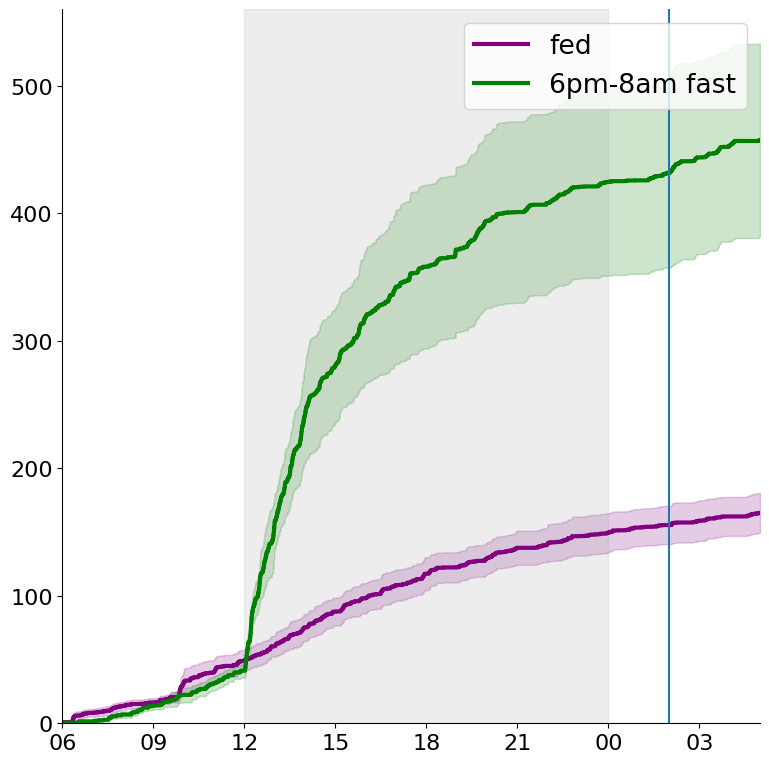

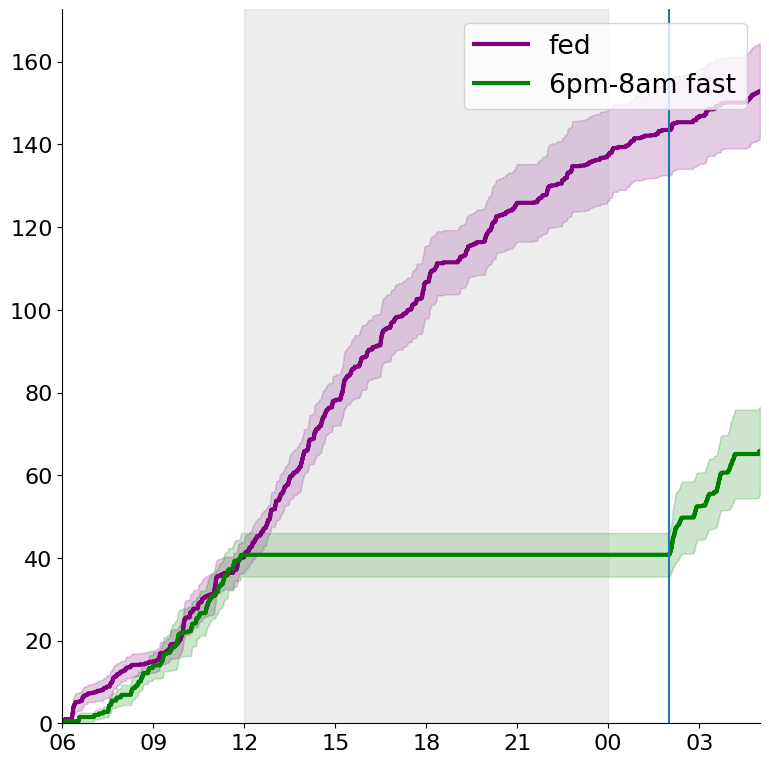

In [62]:
## Two subplots: cumulative poke count, and cumulative pellet count (mean over trials for each condition).

n=0
pokes_means = pd.DataFrame()
pokes_sems = pd.DataFrame()
pellets_means = pd.DataFrame()
pellets_sems = pd.DataFrame()
for Cond in ConditionsToPlot:
    pokes_means[Cond] = AllTrials['Pokes_Pellets']['pokes_cum_ts'].xs(Cond,level='Cond',axis=1).mean(axis=1)
    pokes_sems[Cond] = AllTrials['Pokes_Pellets']['pokes_cum_ts'].xs(Cond,level='Cond',axis=1).sem(axis=1)
    pellets_means[Cond] = AllTrials['Pokes_Pellets']['pellets_cum_ts'].xs(Cond,level='Cond',axis=1).mean(axis=1)
    pellets_sems[Cond] = AllTrials['Pokes_Pellets']['pellets_cum_ts'].xs(Cond,level='Cond',axis=1).sem(axis=1)

fig, ax1 = plot_mean_sem(pokes_means, pokes_sems, ConditionsToPlot=ConditionsToPlot, ColorsToUse=ColorsToUse)
ax1.spines['left'].set_visible(True)
fig, ax2 = plot_mean_sem(pellets_means, pellets_sems, ConditionsToPlot=ConditionsToPlot, ColorsToUse=ColorsToUse)
ax2.spines['left'].set_visible(True)

def set_ylim_to_zero(ax):
    ylim = ax.get_ylim()
    _ = ax.set_ylim([0, ylim[1]])

for ax in [ax1,ax2]:
    set_ylim_to_zero(ax)
    ax.axvline(datetime.datetime(1,1,2,2,0))

figname = "Cumulative pokes, pellets - SEM"
#plt.savefig(figname+'.pdf',facecolor="white")
#plt.savefig(figname+'.png',facecolor="white")

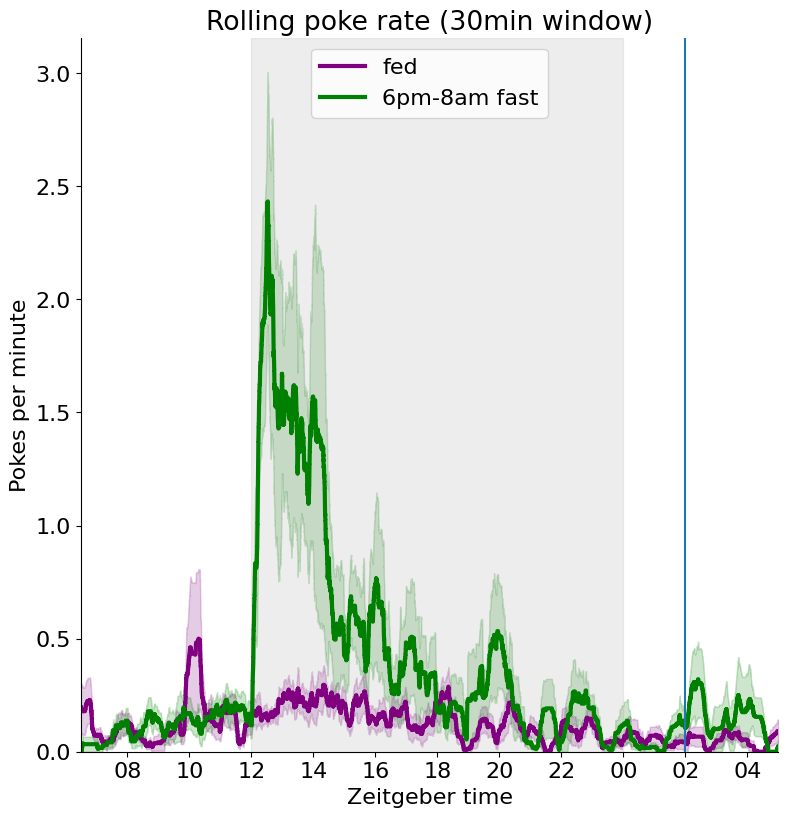

In [63]:
## Rolling poke rate
# take difference of each timepoint of cumulative pokes from the previous one
# then calculate rolling poke rate (30-minute window)
AllTrials['Pokes_Pellets']['poke_rate'] = AllTrials['Pokes_Pellets']['pokes_cum_ts'].diff().rolling(window = 60*30, center=False).mean()*60

means = pd.DataFrame()
sems = pd.DataFrame()

for Cond in ConditionsToPlot:
    means[Cond] = AllTrials['Pokes_Pellets']['poke_rate'].xs(Cond,level='Cond',axis=1).mean(axis=1)
    sems[Cond] = AllTrials['Pokes_Pellets']['poke_rate'].xs(Cond,level='Cond',axis=1).sem(axis=1)

# now plot
fig,ax1 = plot_mean_sem(means, sems, ConditionsToPlot=ConditionsToPlot, ColorsToUse=ColorsToUse)

ax1.spines['left'].set_visible(True)
set_ylim_to_zero(ax1)
ax1.set_ylabel('Pokes per minute')
ax1.set_xlabel('Zeitgeber time')
ax1.set_title('Rolling poke rate (30min window)')
ax1.legend()
ax1.axvline(datetime.datetime(1,1,2,2,0))

figname = "Rolling poke rate"
#plt.savefig(figname+'.pdf')
#plt.savefig(figname+'.png')

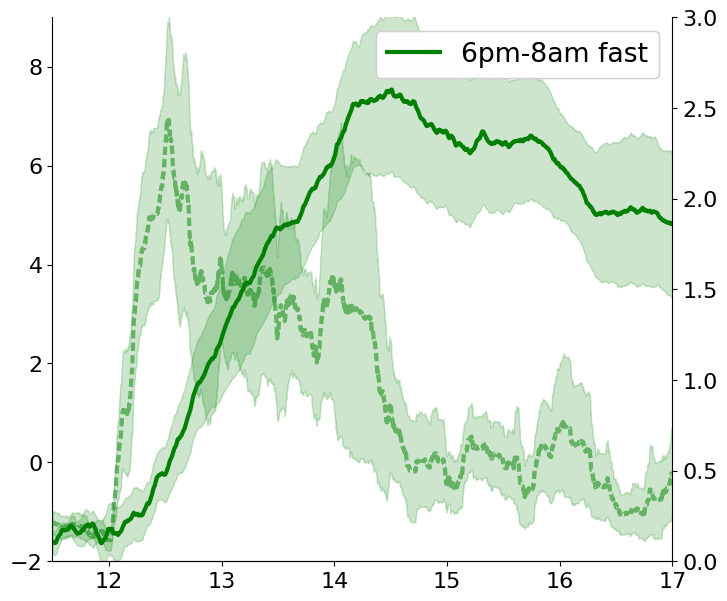

In [64]:
plot_start = datetime.datetime(1,1,1,11,30)
plot_end = datetime.datetime(1,1,1,17,0)

select_conditions = ConditionsToPlot[1:]
select_colors = ColorsToUse[1:]

fig,ax = plt.subplots(1,1,figsize=(8,8))
ax = plot_sem_ax(Mean_Over_Mice[30]['z-score'][plot_start:plot_end][select_conditions],
                    SEM_Over_Mice[30]['z-score'][plot_start:plot_end][select_conditions],
                    ConditionsToPlot=select_conditions,
                    ColorsToUse=select_colors,
                    ax=ax)

ax2 = ax.twinx()
ax2 = plot_sem_ax(means[plot_start:plot_end][select_conditions],
                    sems[plot_start:plot_end][select_conditions],
                    ConditionsToPlot=select_conditions,
                    ColorsToUse=select_colors,
                    ax=ax2)
ax2.set_ylim([0,3])
for ind,cond in enumerate(select_conditions):
    ax2.get_lines()[ind].set_dashes([2,1])
    ax2.get_lines()[ind].set_alpha(0.5)
    ax2.collections[ind].set_alpha(0.2)

ax.spines['left'].set_visible(True)
ax2.spines['right'].set_visible(True)
ax.set_ylim([-2,9])

figname = "zs_mm30 and poke rate - zoom"
#plt.savefig(figname+'.pdf')
#plt.savefig(figname+'.png')

# Poke-triggered activity

In [65]:
# Recalculate activity aligned to pokes
import math
poke_pre_time = 45 #seconds
poke_post_time = 100 #seconds


# Initialize dataframe
PokeTriggered = {'Raw': pd.DataFrame(),
                 'dFF0': pd.DataFrame(),
                 'z-score': pd.DataFrame()
                 }

period_times = {
    'PreFast': [datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,1,12,0)],
    'Fast': [datetime.datetime(1,1,1,12,0),datetime.datetime(1,1,2,2,0)],
    'Refeed': [datetime.datetime(1,1,2,2,0),datetime.datetime(1,1,2,5,0)]
    }


# create Gaussian filter
sigma=10*0.1
width = math.ceil((6*sigma - 1)/2)
support = list(range(-width,width+1))
gaussFilter=[]
for i in support:
    gaussFilter.append(math.exp( (-i**2)/(2*(sigma**2)) ))
sumFilter=sum(gaussFilter)
for i in range(len(gaussFilter)):
    gaussFilter[i]=gaussFilter[i]/sumFilter

#
for trial in AllTrials['Raw_DS'].columns:
    # filter the data with Gaussian, then downsample to 1Hz
    trial_raw = np.convolve(AllTrials['Raw'][trial],gaussFilter,mode='valid')
    trial_raw = pd.DataFrame(trial_raw, index = AllTrials['Raw'][trial].index[width:0-width])
    trial_raw = trial_raw.loc[date_range(trial_raw.index[0].replace(microsecond=0) + datetime.timedelta(seconds=1),
                                        trial_raw.index[-1].replace(microsecond=0),
                                        1, 'seconds')
                            ]
    # get pokes for this trial
    this_trial_pokes = AllTrials['Pokes_Pellets']['pokes_ts'].xs(trial[1],level=1,axis=1)
    trial_pokes_array = this_trial_pokes[this_trial_pokes.iloc[:,0].notnull()].values.flatten()
    for period in period_times.keys():
        period_pokes = trial_pokes_array[trial_pokes_array >= period_times[period][0]]
        period_pokes = period_pokes[period_pokes < period_times[period][1]]
        # each poke in this period for this trial
        for poke in period_pokes:
            # get raw fluorescence around this poke
            poke_aligned_index = date_range(poke - datetime.timedelta(seconds=poke_pre_time),
                                                poke + datetime.timedelta(seconds=poke_post_time),
                                                1, 'seconds')
            poke_aligned_raw = trial_raw.loc[poke_aligned_index].copy()
            poke_aligned_raw.index = np.arange(0-poke_pre_time, 1+poke_post_time)
            # add to dataframe
            cols = pd.MultiIndex.from_arrays([[trial[0]],[trial[1]],[trial[2]],[period],[poke]])
            poke_aligned_raw.columns = cols
            PokeTriggered['Raw'] = pd.concat([PokeTriggered['Raw'],
                                              poke_aligned_raw],
                                              axis=1)

# calculate dF/F0 and z-score
for period in period_times.keys():
    f0 = PokeTriggered['Raw'].loc[-45:-1].mean()
    PokeTriggered['dFF0'] = (PokeTriggered['Raw'] - f0) / f0
    mn = PokeTriggered['dFF0'].loc[-45:-1].mean()
    sd = PokeTriggered['dFF0'].loc[-45:-1].std()
    PokeTriggered['z-score'] = (PokeTriggered['dFF0'] - mn) / sd
    # add column level names
    PokeTriggered['Raw'].columns = PokeTriggered['Raw'].columns.set_names(['MouseID','MouseTrialID','Condition','Period','Poke_Time'])
    PokeTriggered['dFF0'].columns = PokeTriggered['dFF0'].columns.set_names(['MouseID','MouseTrialID','Condition','Period','Poke_Time'])
    PokeTriggered['z-score'].columns = PokeTriggered['z-score'].columns.set_names(['MouseID','MouseTrialID','Condition','Period','Poke_Time'])

# Take mean over all pokes per period per trial
PokeTriggered_MeanPerTrial = PokeTriggered['z-score'].groupby(level=[1,2,3], axis=1).mean()

## Figures 4F and S14A
Now plot average poke-triggered activity over all pokes from all mice.

Because pokes are often grouped into bouts, pokes may be preceded by other pokes - in other words, the "baseline" activity during the pre-poke period (45 seconds) may be contaminated by activity related to other pokes. To avoid this, let's also plot activity triggered to "lone pokes" - i.e. pokes that have no other pokes within the pre-poke period.

In [66]:
poke_time_threshold = 45
n=0
leg = []
leg_handles = []
my_cols = pd.MultiIndex(levels = [[],[],[],[]], codes = [[],[],[],[]],
                            names = [u'Condition',u'Period',u'MouseTrialID',u'PokeTime'])
Lone_Pokes = pd.DataFrame(columns=my_cols)
Periods = PokeTriggered['z-score'].columns.get_level_values(3).unique()
for Period in Periods:
    for Cond in ConditionsToPlot:
        # get poke-aligned traces for all pokes in this period corresponding to this condition
        This_Stim_Trials = PokeTriggered['z-score'].xs((Cond,Period), level=(2,3), axis=1)
        # calculate mean and SEM over all pokes in this period/condition
        MN = This_Stim_Trials.mean(axis=1)
        SE = This_Stim_Trials.sem(axis=1)

        # now get the "lone pokes" - loop through trials
        Lone_Pokes_cond = pd.DataFrame(columns=my_cols)
        This_Stim_Trials.columns = This_Stim_Trials.columns.droplevel(0)
        for trial in list(set(This_Stim_Trials.columns.get_level_values(0))):
            Poke_Times = list(This_Stim_Trials[trial].columns)
            # take the poke times where the preceding poke is >X seconds before
            Lone_Poke_Times = [v for i,v in enumerate(Poke_Times) if v - Poke_Times[i-1] > datetime.timedelta(seconds=poke_time_threshold)]
            # add the first poke
            if len(Poke_Times)>0:
                Lone_Poke_Times = [Poke_Times[0]] + Lone_Poke_Times
            Lone_Pokes_cond = pd.concat([Lone_Pokes_cond,This_Stim_Trials.loc[:,(trial,Lone_Poke_Times)]],axis=1)
        # add condition to columns, and add lone pokes from this condition to dataframe
        old_col = Lone_Pokes_cond.columns.to_frame()
        old_col.insert(0, 'Cond', [Cond]*len(Lone_Pokes_cond.columns))
        old_col.insert(1,'Period', [Period]*len(Lone_Pokes_cond.columns))
        old_col.columns = ['Condition','Period','MouseTrialID','PokeTime']
        Lone_Pokes_cond.columns = pd.MultiIndex.from_frame(old_col)
        Lone_Pokes = pd.concat([Lone_Pokes,Lone_Pokes_cond], axis=1)
        # take mean and SEM over lone poke-aligned traces, and plot
        MN = Lone_Pokes_cond.mean(axis=1)
        SE = Lone_Pokes_cond.sem(axis=1)
        n=n+1
Lone_Pokes.sort_index(axis=1,level='Condition',inplace=True)

% lone pokes = 0
6pm-8am fast    16.721311
fed             37.348485
dtype: float64


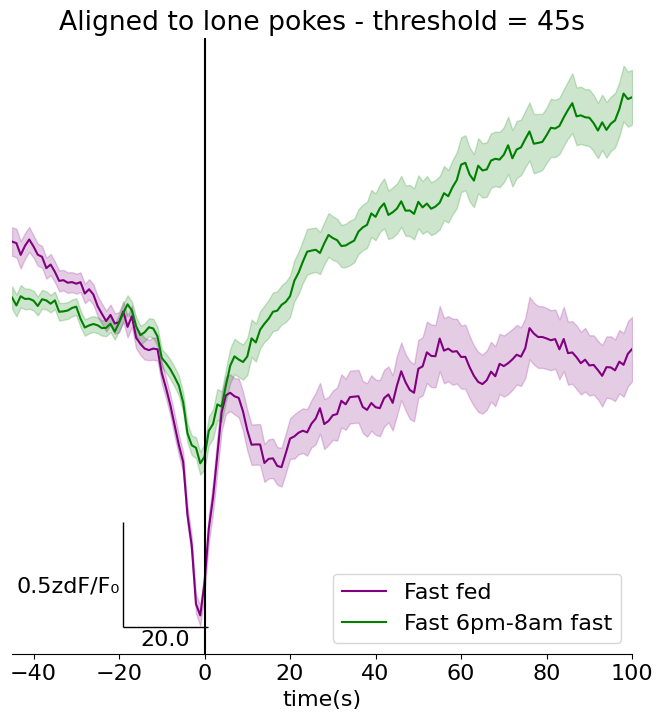

In [67]:
# pokes - just fast period
fig,ax = plt.subplots(1,1,figsize=(8,8))

colorlist = ["#a6cee3", "#1f78b4","purple","green","#fdbf6f","#ff7f00"]
Period = 'Fast'
cpal = sns.color_palette(colorlist)
n=2
leg = []
for Cond in ConditionsToPlot:
     # get poke-aligned traces for all pokes in this period corresponding to this condition
    This_Stim_Trials = PokeTriggered['z-score'].xs((Cond,Period), level=(2,3), axis=1)
    # calculate mean and SEM over all pokes in this period/condition
    # take mean and SEM over lone poke-aligned traces, and plot
    MN = Lone_Pokes[Cond,Period].mean(axis=1)
    SE = Lone_Pokes[Cond,Period].sem(axis=1)
    leg_ha = ax.plot(MN,color=cpal[n], label=Period + ' ' + Cond)
    leg_handles = leg_ha.append(leg_ha)
    ax.fill_between(list(MN.index), MN.subtract(SE, fill_value=0).tolist(), MN.add(SE, fill_value=0).tolist(), color = cpal[n], alpha=0.2)
    n=n+1

# plot vertical line at t=0
ax.axvline(x=0, color='black')

# set axis properties, add legend
ax.set(xlabel="time(s)", ylabel="dF/F0", title=f"Aligned to lone pokes - threshold = {poke_time_threshold}s")
ax.legend(handles=leg_handles)

_ = add_scalebar(ax, matchx=True, matchy=False, hidex=False, hidey=True,
                sizey=0.5, labely=u'0.5zdF/F\u2080', loc='lower left')
for loc in ['top','right','left']:
    ax.spines[loc].set_visible(False)

pct_lone_pokes = 100* pd.DataFrame(list(Lone_Pokes.columns)).groupby(0).count()[1] / pd.DataFrame(list(PokeTriggered['z-score'].columns)).groupby(2).count()[0]
print(f"% lone pokes = {pct_lone_pokes}")
# save figure as png and svg
#fig.savefig(f'Poke-aligned activity mean over pokes fast only - threshold = {poke_time_threshold}s.png',facecolor="white")
#fig.savefig(f'Poke-aligned activity mean over pokes fast only - threshold = {poke_time_threshold}s.pdf',facecolor="white")

## Figure S15A
Look at poking curve - bin poke-aligned activity at different points on this curve

(-45.0, 60.0)

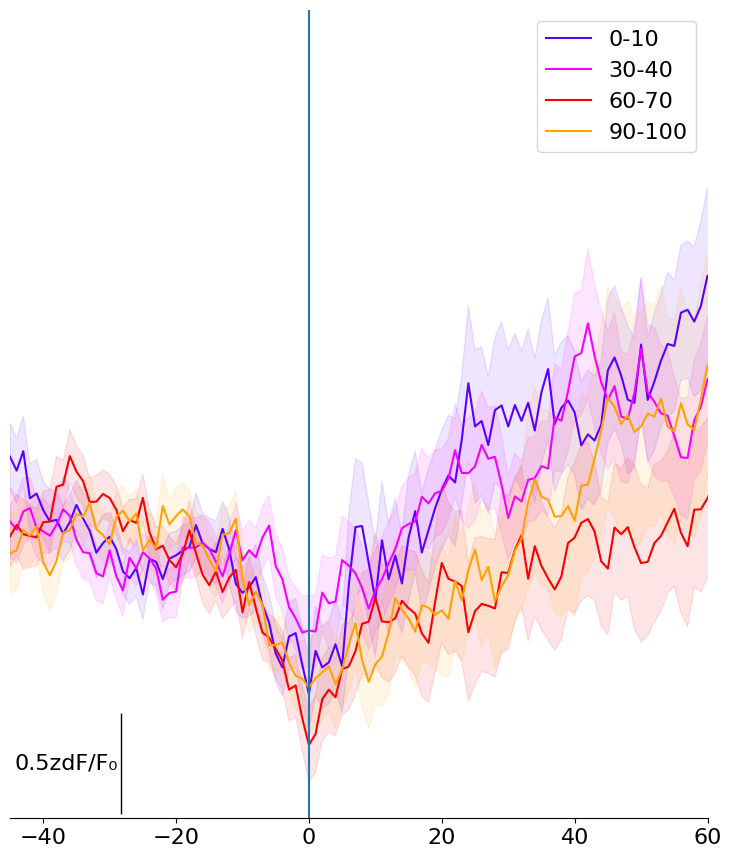

In [68]:
# Poke response by percentile over fast
fast_cond = '6pm-8am fast'
pctiles = {'0-10': [0,0.1],
           '30-40': [0.3,0.4],
           '60-70': [0.6,0.7],
           '90-100': [0.9,1.0]
           }
sequential_cmap = colormaps['inferno'].resampled(len(pctiles))
cmap = ['#5A00FF','#F600FF','#FB0001','#FFA300']

LonePokeTriggered_by_lone_pctile = pd.DataFrame()

data_to_use = Lone_Pokes[fast_cond].xs('Fast',level='Period',axis=1)

for trial in data_to_use.columns.get_level_values(0).unique():
    trial_lone_pokes = list(data_to_use[trial].columns)
    trial_lone_pokes = pd.DataFrame({'poke_time': trial_lone_pokes,
                                     'frac_lone_pokes': [(i+1)/len(trial_lone_pokes) for i,j in enumerate(trial_lone_pokes)]})
    # get lone-poke-aligned traces for this trial
    this_trial_pokes = Lone_Pokes[fast_cond]['Fast'][trial]

    for pctile in pctiles.keys():
        pokes_in_pctile = trial_lone_pokes['poke_time'][trial_lone_pokes['frac_lone_pokes'] > pctiles[pctile][0]]
        pokes_in_pctile = pokes_in_pctile[trial_lone_pokes['frac_lone_pokes'] < pctiles[pctile][1]]
        pokes_in_pctile = this_trial_pokes[list(pokes_in_pctile)]
        pokes_in_pctile.columns = pd.MultiIndex.from_arrays([[pctile]*len(pokes_in_pctile.columns),
                                                            [fast_cond]*len(pokes_in_pctile.columns),
                                                            [trial]*len(pokes_in_pctile.columns),
                                                            pokes_in_pctile.columns
                                                            ])
        LonePokeTriggered_by_lone_pctile = pd.concat([LonePokeTriggered_by_lone_pctile, pokes_in_pctile], axis=1)

# Plot
df = LonePokeTriggered_by_lone_pctile.xs(fast_cond,level=1,axis=1)
fig, ax = plt.subplots(1,1)
mn = df.groupby(level=0,axis=1).mean()
_ = mn[[x for x in list(pctiles.keys()) if x in mn.columns]].plot(color=cmap, ax=ax)
for n,percentile in enumerate(list(mn.columns)):
    df1 = df[percentile]
    ax.fill_between(df1.index,
                    np.add(df1.mean(axis=1), df1.sem(axis=1).tolist()),
                    np.subtract(df1.mean(axis=1), df1.sem(axis=1).tolist()),
                    alpha=0.1, color=cmap[n])
ax.axvline(0)

_ = add_scalebar(ax, matchx=False, matchy=False, hidex=False, hidey=True, sizex=0,
                    sizey=0.5, labely=u'0.5zdF/F\u2080', loc='lower left')

for loc in ['top','right','left']:
    ax.spines[loc].set_visible(False)

ax.set_xlim([-45,60])

# save figure as png and pdf
#fig.savefig('Lone poke-aligned activity, fast, by percentile of lone pokes.png',facecolor="white")
#fig.savefig('Lone poke-aligned activity, fast, by percentile of lone pokes.pdf',facecolor="white")